In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pgs-data/METER_HISTORY.xls
/kaggle/input/pgs-data/Orders2.xls
/kaggle/input/pgs-data/ORDER_RECIPE4.xls
/kaggle/input/pgs-data/Bulk_movement.xls
/kaggle/input/pgs-data/BULK_PRODUCT.xls
/kaggle/input/pgs-data/ORDER_RECIPE7.xls
/kaggle/input/pgs-data/ORDER_RECIPE5.xls
/kaggle/input/pgs-data/ORDER_RECIPE1.xls
/kaggle/input/pgs-data/Orders.xls
/kaggle/input/pgs-data/ORDER_RECIPE3.xls
/kaggle/input/pgs-data/CONTAINER.xls
/kaggle/input/pgs-data/ORDERS_TANK_INV.xls
/kaggle/input/pgs-data/ORDER_RECIPE8.xls
/kaggle/input/pgs-data/ORDERS_TANK_INV2.xls
/kaggle/input/pgs-data/BOOK_INVENTORY_HISTORY.xls
/kaggle/input/pgs-data/COMPARTMENT.xls
/kaggle/input/pgs-data/TRAILER.xls
/kaggle/input/pgs-data/TRACTOR.xls
/kaggle/input/pgs-data/INJECTOR_HISTORY.xls
/kaggle/input/pgs-data/ORDER_RECIPE2.xls
/kaggle/input/pgs-data/ORDER_RECIPE6.xls


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install xlrd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
file_path_orders = '/kaggle/input/pgs-data/Orders.xls' 
file_path_ordersRecipe = '/kaggle/input/pgs-data/ORDER_RECIPE1.xls' 

df_orders = pd.read_excel(file_path_orders)
df_recipe = pd.read_excel(file_path_ordersRecipe)

In [5]:
df_orders.head()

,ORDER_ID,LOADED_DRIVER_NUMBER,USER_NAME,TRAILER_CARRIER_NUMBER,CARRIER_NUMBER,TRAILER_CODE,VEHICLE_CARRIER_NUMBER,VEHICLE_CODE,TRACTOR_CARRIER_NUMBER,LOADED_CARRIER_NUMBER,...,PREV_ORDER_ID,SIGNATURE_PATH,SIGNATURE_FILE_NAME,PDXR_AUTHORIZING_SYSTEM,START_TIMESLOT_DATETIME,END_TIMESLOT_DATETIME,START_PICKUP_DATETIME,END_PICKUP_DATETIME,ADMINISTRATIVE_BOOKING,Unnamed: 138
0,8320,158,NaN,NaN,1,NaN,NaN,NaN,1.0,1,...,8320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,12128,6,NaN,NaN,1,NaN,NaN,NaN,1.0,1,...,12128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,19110,105,NaN,NaN,1,NaN,NaN,NaN,1.0,1,...,19110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,19143,171,NaN,NaN,1,NaN,NaN,NaN,1.0,1,...,19143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
4,19176,149,NaN,NaN,1,NaN,NaN,NaN,1.0,1,...,19176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [6]:
# Select relevant columns from the 1st dataset
cols_df1 = ['ORDER_ID','ORDERED_QUANTITY', 
            'TERMINAL_PRODUCT_NUMBER', 'CUSTOMER_NET_QUANTITY']

df1_selected = df_recipe[cols_df1]

# Select relevant columns from the 2nd dataset
cols_df2 = ['ORDER_ID','CUSTOMER_NUMBER',
            'START_LOAD_TIME']

df2_selected = df_orders[cols_df2]

# Merge datasets on 'ORDER_ID'
merged_df = pd.merge(df1_selected, df2_selected, on='ORDER_ID', how='inner')

# Print the merged dataframe


In [7]:
merged_df.head(20)

,ORDER_ID,ORDERED_QUANTITY,TERMINAL_PRODUCT_NUMBER,CUSTOMER_NET_QUANTITY,CUSTOMER_NUMBER,START_LOAD_TIME
0,8320,100,7,0,12,2021-09-24 14:21:37.000
1,8320,100,7,0,12,2021-09-24 14:21:37.000
2,8320,100,7,0,12,2021-09-24 14:21:37.000
3,8320,671,7,664,12,2021-09-24 14:21:37.000
4,8320,100,7,0,12,2021-09-24 14:21:37.000
5,8320,100,7,0,12,2021-09-24 14:21:37.000
6,8320,100,7,0,12,2021-09-24 14:21:37.000
7,12128,8000,7,0,13,2021-09-28 10:08:35.607
8,12128,3000,4,0,13,2021-09-28 10:08:35.607
9,12128,2000,7,0,13,2021-09-28 10:08:35.607


In [8]:
merged_df.shape

(65535, 6)

In [9]:
merged_df = merged_df.dropna(subset=['CUSTOMER_NET_QUANTITY'])

In [10]:
merged_df = merged_df[merged_df['CUSTOMER_NET_QUANTITY'] != 0]

In [11]:
merged_df.head()

,ORDER_ID,ORDERED_QUANTITY,TERMINAL_PRODUCT_NUMBER,CUSTOMER_NET_QUANTITY,CUSTOMER_NUMBER,START_LOAD_TIME
3,8320,671,7,664,12,2021-09-24 14:21:37
14,19110,10000,7,9905,12,2021-09-27 12:11:36
15,19110,2000,7,1977,12,2021-09-27 12:11:36
18,19110,10000,7,9902,12,2021-09-27 12:11:36
19,19143,11000,7,10895,12,2021-09-27 12:11:42


In [12]:
merged_df.tail()

,ORDER_ID,ORDERED_QUANTITY,TERMINAL_PRODUCT_NUMBER,CUSTOMER_NET_QUANTITY,CUSTOMER_NUMBER,START_LOAD_TIME
65530,389752,4000,7,91,13,2021-12-17 14:29:26
65531,389752,10000,7,7392,13,2021-12-17 14:29:26
65532,389752,10000,7,2586,13,2021-12-17 14:29:26
65533,389786,8000,7,7980,3,2021-12-17 14:34:39
65534,389786,2400,8,2401,3,2021-12-17 14:34:39


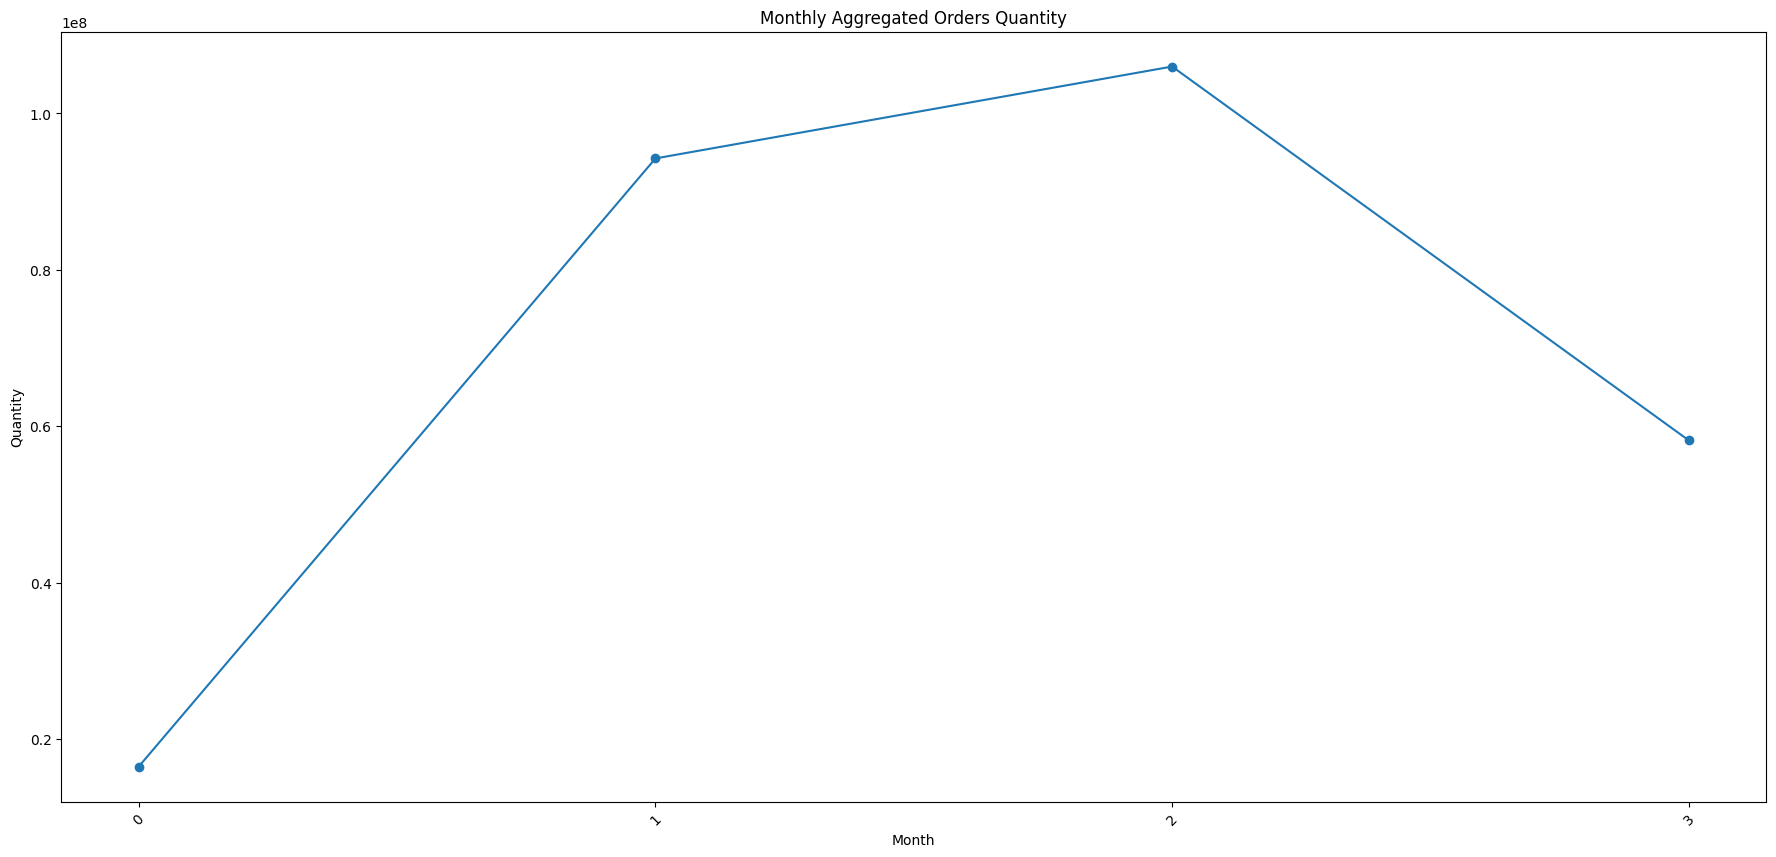

In [17]:
merged_df['START_LOAD_TIME'] = pd.to_datetime(merged_df['START_LOAD_TIME'])

plt.figure(figsize=(22, 10))
plt.plot(monthly_aggregated.index.astype(str), monthly_aggregated['ORDERED_QUANTITY'], marker='o')
plt.title("Monthly Aggregated Orders Quantity")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()